In [1]:
# License: BSD
# Author: Sasank Chilamkurthy

from __future__ import print_function, division

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy

cudnn.benchmark = True
plt.ion()   # interactive mode


/home/mahirwar/anaconda3/envs/amy_plague/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Classification Task

In [2]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(256),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir =  "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images/split_data"
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val', 'test']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val','test']}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [3]:
class_names

['White', 'bg', 'grey']

torch.Size([4, 3, 256, 256])
(260, 1034, 3)


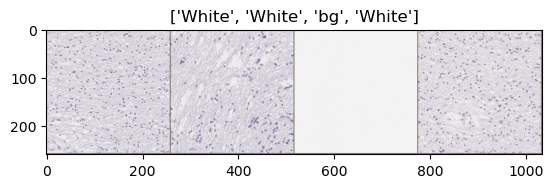

In [4]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    print(inp.shape)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

print(inputs.shape)

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [5]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

In [6]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)


In [7]:
model_ft = models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = nn.Linear(num_ftrs, 3)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [8]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=50)

Epoch 0/49
----------


/home/mahirwar/anaconda3/envs/amy_plague/lib/python3.8/site-packages/torch/nn/functional.py:718: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at  /tmp/pip-req-build-pyrtjkcs/c10/core/TensorImpl.h:1156.)
  return torch.max_pool2d(input, kernel_size, stride, padding, dilation, ceil_mode)


train Loss: 0.2941 Acc: 0.9091
val Loss: 0.1428 Acc: 0.9464

Epoch 1/49
----------
train Loss: 0.1488 Acc: 0.9570
val Loss: 0.0553 Acc: 1.0000

Epoch 2/49
----------
train Loss: 0.1089 Acc: 0.9714
val Loss: 0.0569 Acc: 0.9888

Epoch 3/49
----------
train Loss: 0.0738 Acc: 0.9789
val Loss: 0.0937 Acc: 0.9453

Epoch 4/49
----------
train Loss: 0.0653 Acc: 0.9807
val Loss: 0.0161 Acc: 1.0000

Epoch 5/49
----------
train Loss: 0.0545 Acc: 0.9842
val Loss: 0.0046 Acc: 1.0000

Epoch 6/49
----------
train Loss: 0.0560 Acc: 0.9848
val Loss: 0.0063 Acc: 1.0000

Epoch 7/49
----------
train Loss: 0.0317 Acc: 0.9908
val Loss: 0.0112 Acc: 1.0000

Epoch 8/49
----------
train Loss: 0.0257 Acc: 0.9929
val Loss: 0.0114 Acc: 0.9989

Epoch 9/49
----------
train Loss: 0.0260 Acc: 0.9915
val Loss: 0.0096 Acc: 0.9978

Epoch 10/49
----------
train Loss: 0.0231 Acc: 0.9934
val Loss: 0.0151 Acc: 0.9955

Epoch 11/49
----------
train Loss: 0.0223 Acc: 0.9932
val Loss: 0.0168 Acc: 0.9978

Epoch 12/49
----------
t

(256, 256, 3)


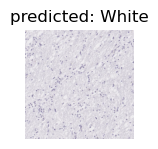

(256, 256, 3)


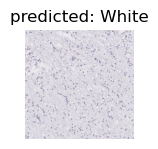

(256, 256, 3)


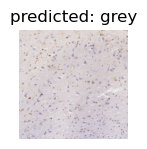

(256, 256, 3)


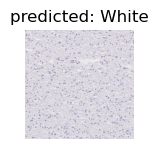

(256, 256, 3)


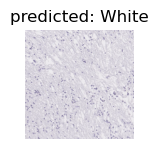

(256, 256, 3)


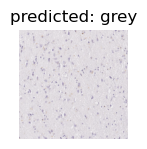

In [9]:
visualize_model(model_ft)

In [10]:
torch.save({"model":model_ft, "state": model_ft.state_dict()}, 'model_full2.pth')

In [11]:
from sklearn.metrics import classification_report
def test_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    #fig = plt.figure()
    # White 0, grey 1 bg 2
    map_label = {"White":0, "grey": 2, "bg": 1}
    actual_labels = []
    pred_labels = []
    target_names =  class_names
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['test']):
            inputs = inputs.to(device)
            labels = labels.to(device)
            #print(labels.tolist())
            actual_labels.extend(labels.tolist())

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            #print(preds)
            pred_labels.extend(preds.tolist())
    print(actual_labels)
    print(pred_labels)
    lst3 = [i for i, j in zip(actual_labels, pred_labels) if i != j]
    print(lst3)
    print(classification_report(actual_labels, pred_labels, target_names=target_names))

            #for j in range(inputs.size()[0]):
            #    images_so_far += 1
            #    ax = plt.subplot(num_images//2, 2, images_so_far)
            #    ax.axis('off')
            #    ax.set_title(f'predicted: {class_names[preds[j]]}')
            #    imshow(inputs.cpu().data[j])

            #   if images_so_far == num_images:
            #        model.train(mode=was_training)
            #        return
        #model.train(mode=was_training)

In [12]:
test_model(model_ft, num_images=6)

[0, 2, 2, 0, 1, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 2, 1, 0, 0, 0, 0, 2, 0, 2, 0, 0, 2, 1, 2, 0, 1, 1, 0, 2, 2, 0, 0, 1, 2, 0, 1, 0, 1, 2, 0, 0, 2, 0, 0, 1, 2, 0, 0, 2, 2, 2, 0, 0, 1, 2, 0, 0, 2, 2, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 1, 2, 2, 0, 2, 2, 2, 0, 0, 2, 0, 0, 2, 1, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 2, 0, 0, 0, 0, 1, 1, 0, 2, 1, 0, 2, 0, 2, 1, 0, 2, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 1, 1, 0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0, 1, 0, 2, 0, 1, 2, 2, 0, 1, 0, 2, 2, 0, 1, 1, 2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 0, 2, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 2, 2, 0, 2, 0, 0, 1, 0, 2, 0, 0, 1, 2, 2, 0, 0, 0, 2, 2, 0, 0, 2, 2, 2, 2, 1, 0, 2, 1, 2, 2, 1, 1, 0, 2, 2, 1, 2, 0, 0, 2, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 1, 1, 0, 2, 0, 0, 1, 0, 2, 2, 0, 2, 2, 1, 2, 0, 2, 1, 0, 2, 2, 2, 0, 2, 1, 0, 0, 0, 1, 2, 1, 1, 2, 2, 0, 1, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 

# Segmentation Task

In [13]:
import pyvips as Vips
import numpy as np

In [15]:
def getVipsInfo(vips_img):
    # # Get bounds-x and bounds-y offeset
    vfields = [f.split('.') for f in vips_img.get_fields()]
    vfields = [f for f in vfields if f[0] == 'openslide']
    vfields = dict([('.'.join(k[1:]), vips_img.get('.'.join(k))) for k in vfields])
    return vfields


img  =  '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/11_063_CG_aSyn_x200.svs'

vips_img = Vips.Image.new_from_file(img, level=0)
vinfo = getVipsInfo(vips_img)
orig_w, orig_h = int(vinfo['level[0].width']), int(vinfo['level[0].height'])
vips_array = np.ndarray(buffer=vips_img.write_to_memory(), dtype=np.uint8, shape=(vips_img.height, vips_img.width, vips_img.bands))
vips_array = vips_array[:,:,:3]
vips_array_copy =vips_array.copy()

In [12]:
## Load model

model_ft = models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = nn.Linear(num_ftrs, 3)
model_ft = model_ft.to(device)

model_ft.load_state_dict(torch.load('model_weights.pth'))

In [13]:
ls

create_data_for_WGB_segmentation.py  make_dataset.py    split_data.py
create_data.ipynb                    model_full.pth     train_data/
__init__.py                          model_weights.pth  WM_Classification.ipynb


In [17]:
checkpoint = torch.load('model_full.pth')
model_ft = checkpoint["model"]
model_ft.load_state_dict(checkpoint['state'])

<All keys matched successfully>

In [31]:
def predict_crop_class(model_ft, crop):
    crop_array = np.ndarray(buffer=crop.write_to_memory(), dtype=np.uint8, shape=(tilesize, tilesize, crop.bands))
    crop_array = crop_array[:,:,:3]
    crop_array = torch.from_numpy(crop_array.transpose((2,0,1)))
    crop_array = torch.unsqueeze(crop_array, dim=0)
    outputs = model_ft(crop_array.to(device).float())
    _, preds = torch.max(outputs, 1)
    return preds.tolist()




stride = 512
tilesize = 1024
masked_image = np.zeros((orig_w, orig_h, 3))
for x_val in range(0, orig_w-stride, stride): 
    for y_val in range(0, orig_h-stride, stride):
        if y_val + tilesize < orig_h and x_val + tilesize < orig_w:
            crop = vips_img.crop(x_val, y_val, tilesize, tilesize)
            crop_pred =  predict_crop_class(model_ft, crop)
            if crop_pred==[0]:
                masked_image[x_val:x_val+tilesize, y_val:y_val+tilesize] = [0,0,255]
            if crop_pred==[1]:
                masked_image[x_val:x_val+tilesize, y_val:y_val+tilesize] = [255,0,0]
            if crop_pred==[2]:
                masked_image[x_val:x_val+tilesize, y_val:y_val+tilesize] = [0,255,0]

In [32]:
masked_image.shape

(53783, 33339, 3)

In [33]:
from PIL import Image
th = Image.fromarray(masked_image.astype(np.uint8))
#th.thumbnail((1000,1000, 3))

In [34]:
th.thumbnail((1000,1000))

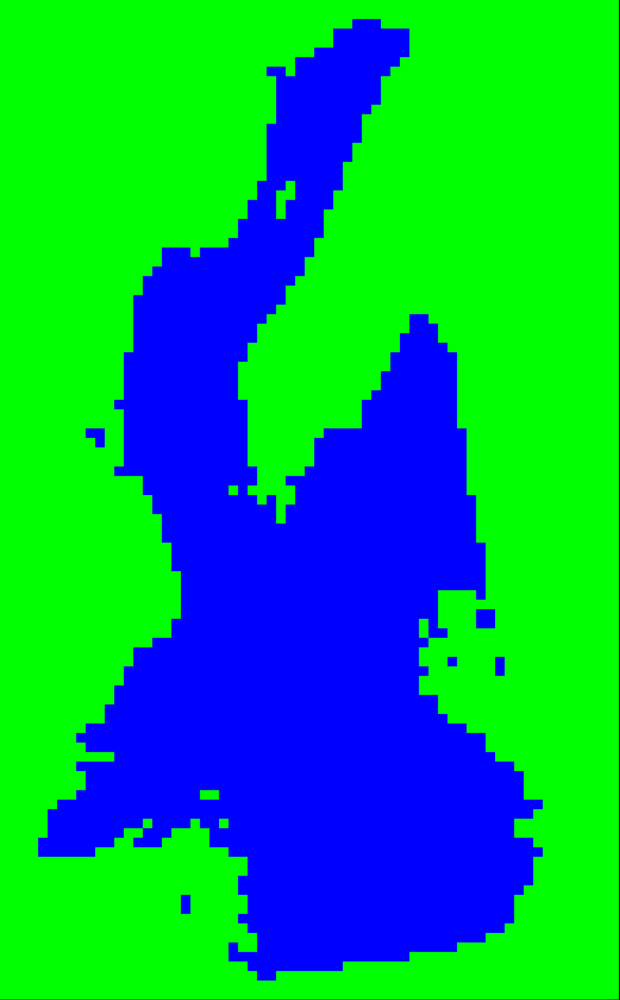

In [35]:
th

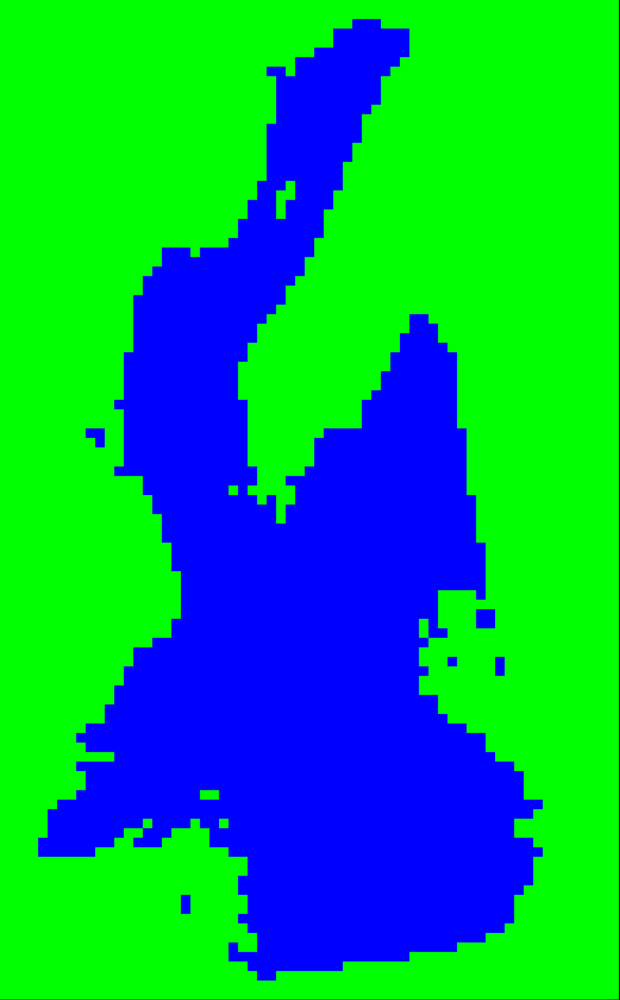

In [30]:
th

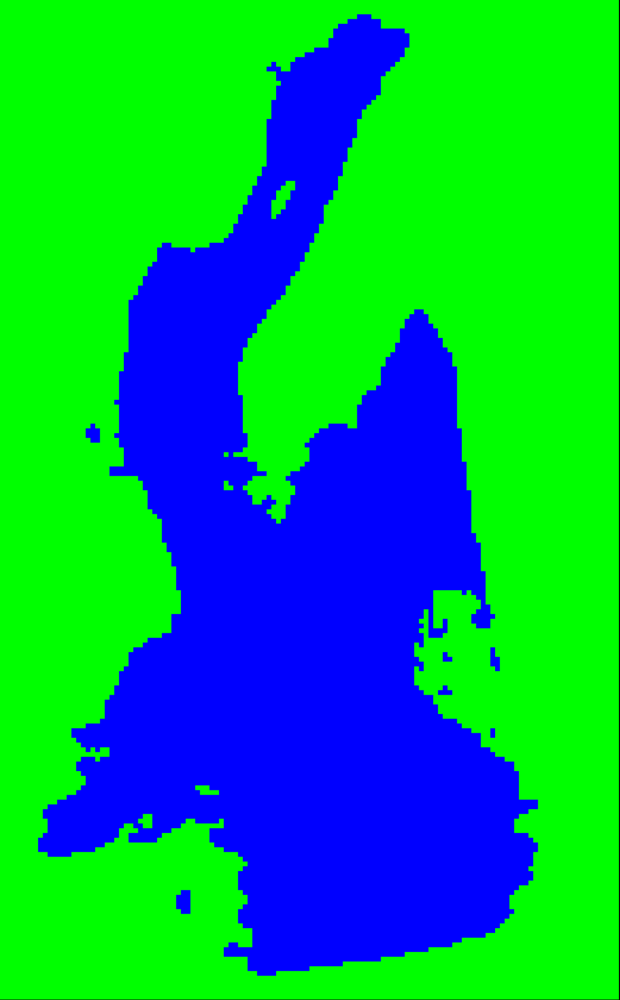

In [20]:
th

In [58]:
th.save(os.path.join("img3.png"))

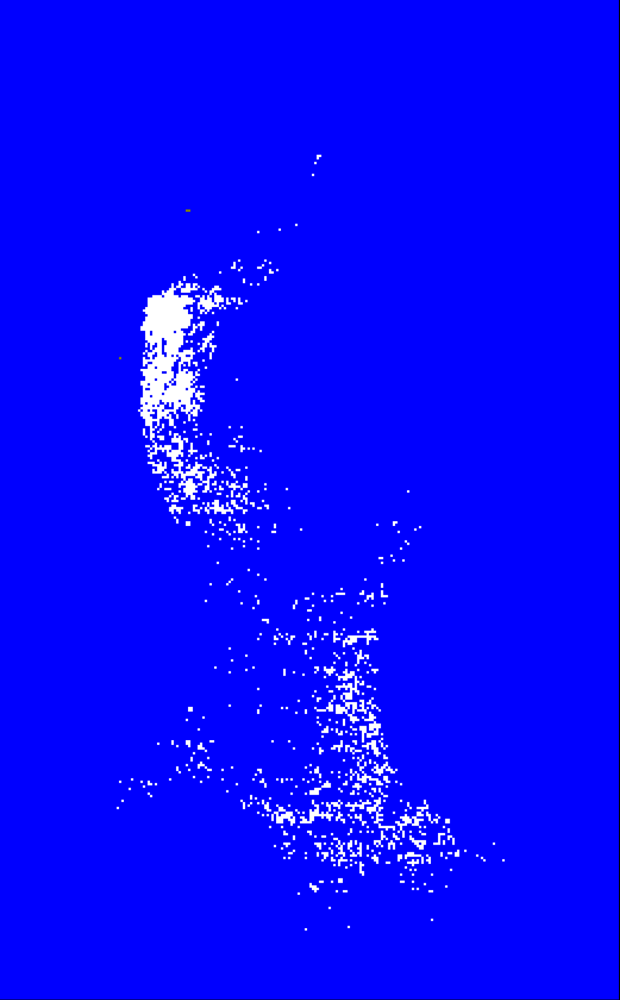

In [42]:
th

In [22]:
masked_image = np.zeros((orig_w, orig_h, 3))
masked_image.shape

(53783, 33339, 3)

In [26]:
x_val = 0
y_val = 0
tilesize = 256
y = 0
if y==0:
    masked_image[x_val:x_val+tilesize, y_val:y_val+tilesize] = [0,0,255]
if y==1:
    masked_image[x_val:x_val+tilesize, y_val:y_val+tilesize] = [255,255,255]
if y==2:
    masked_image[x_val:x_val+tilesize, y_val:y_val+tilesize] = [128,128,0]


In [29]:
masked_image[x_val+tilesize: , y_val+tilesize: ]

array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]])

In [61]:
stride = 128
tilesize = 256
#device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(preds)



tensor([0], device='cuda:0')


In [20]:
import multiprocessing

In [21]:
# Define the parallel processing function
def process_patches(patches):
    # Create a multiprocessing pool with the number of available CPUs
    pool = multiprocessing.Pool(processes=multiprocessing.cpu_count())
    # Apply the mask generation function to each patch in parallel
    masks = pool.map(generate_mask, patches)
    # Close the multiprocessing pool
    pool.close()
    # Merge the resulting masks
    mask = np.zeros_like(masks[0])
    for m in masks:
        mask = cv2.bitwise_or(mask, m)
    return mask

In [62]:
# Split the image into patches
patch_size = (img.shape[0]//4, img.shape[1]//4)
patches = [img[i:i+patch_size[0], j:j+patch_size[1]] for i in range(0, img.shape[0], patch_size[0]) for j in range(0, img.shape[1], patch_size[1])]

# Process the patches in parallel
mask = process_patches(patches)

# Apply the mask to the original image
result = cv2.bitwise_and(img, img, mask=mask)

tensor([[-252.6272, -468.2963, -325.6906]], device='cuda:0',
       grad_fn=<AddmmBackward>)
